In [1]:
import sys
sys.path.insert(0, '..')
from dependencies import *

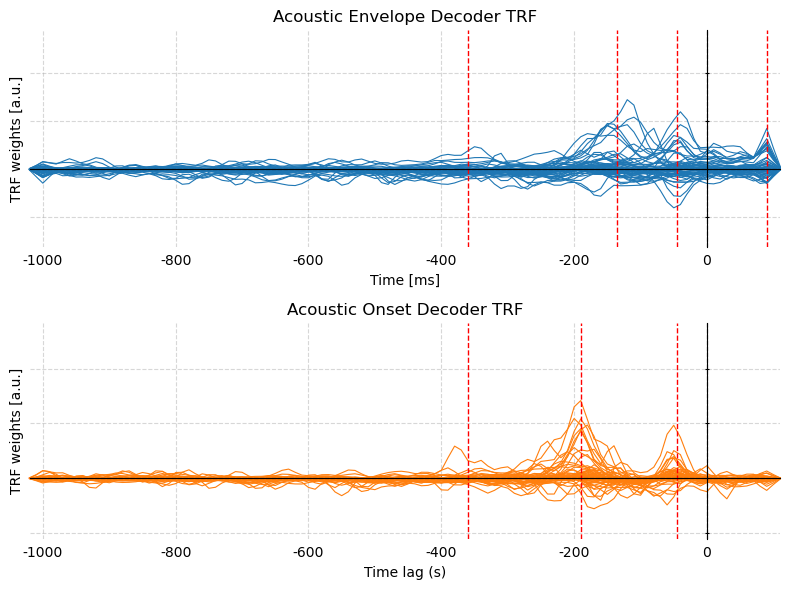

In [5]:
# ------------------------------------------------
# Load universal decoder TRFs
# ------------------------------------------------
decoder_trfs = {
    'log': eelbrain.load.unpickle(TRF_DIR / 'decoder-universal-trf-envelope_log.pickle'),
    'onset': eelbrain.load.unpickle(TRF_DIR / 'decoder-universal-trf-envelope_onset.pickle')
}

# ------------------------------------------------
# DEFINE LATENCIES (in seconds) PER MODEL
# ------------------------------------------------
latencies_dict = {
    'log':   [-0.045, -0.135, -0.360, 0.090],   # Envelope TRF latencies
    'onset': [-0.045, -0.190, -0.360]           # Onset TRF latencies
}

# ------------------------------------------------
# Prepare figure
# ------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

colors = {'log': 'tab:blue', 'onset': 'tab:orange'}

# ------------------------------------------------
# Plot loop
# ------------------------------------------------
for i, model in enumerate(['log', 'onset']):
    trf = decoder_trfs[model]

    # ----------------------------------------
    # Average predictors if needed
    # ----------------------------------------
    if 'predictor' in trf.dims:
        trf_plot = trf.mean('predictor')
    else:
        trf_plot = trf

    # ----------------------------------------
    # Butterfly plot
    # ----------------------------------------
    eelbrain.plot.Butterfly(
        trf_plot,
        axes=axes[i],
        color='tab:blue' if model == 'log' else 'tab:orange',
        linewidth=0.8,
        frame='t',
        yticklabels="none"
    )

    # ----------------------------------------
    # Apply SAME vertical scaling trick
    # ----------------------------------------
    y_min = trf_plot.x.min()
    y_max = trf_plot.x.max()
    axes[i].set_ylim(y_min * 2, y_max * 2)

    # ----------------------------------------
    # Latency lines
    # ----------------------------------------
    latencies = latencies_dict[model]
    for j, t in enumerate(latencies):
        axes[i].axvline(
            t,
            color='red',
            linestyle='--',
            linewidth=1,
            label='Latencies' if j == 0 else None
        )

    # ----------------------------------------
    # Formatting
    # ----------------------------------------
    type_model = 'Acoustic Envelope' if model == 'log' else 'Acoustic Onset'

    axes[i].set_title(type_model + ' Decoder TRF')
    axes[i].set_ylabel('TRF weights [a.u.]')
    axes[i].axhline(0, linestyle='--', color='black', linewidth=0.8)
    axes[i].axvline(0, linestyle='--', color='black', linewidth=0.8)
    axes[i].grid(True, linestyle='--', alpha=0.5)

# Shared x-axis label
axes[-1].set_xlabel('Time lag (s)')

plt.tight_layout()
plt.show()